---

# Task 1: Familiarize Yourself with the Dataset

There are two main subtasks:  
1. Load the four data files that are part of this dataset.  
2. Explore each dataset and define the data types of each column. Describe the contents of each column, including the nature of the data values. Follow a similar approach as demonstrated in the lecture and tutorial. Discuss the shape of the data, value ranges, and possible categories. Convert any data into a more appropriate format if needed.  

Add as many code and markdown cells as necessary below. Typically, you should perform one type of investigation per code cell with output, and then comment on the results in a markdown cell below it.  

After completing the analysis, write a concise summary in the **Task 1: summary report** cell at the end. The final report should succinctly summarize the main characteristics of each data file, how they relate to each other, and any notable features.


In [ ]:
# this is your first code cell, add more cells for code and mardown as needed
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sessions = pd.read_csv('/content/drive/MyDrive/IAT461-ASS1/data/data/sessions.csv')
streamers = pd.read_csv('/content/drive/MyDrive/IAT461-ASS1/data/data/streamers.csv')
streams = pd.read_csv('/content/drive/MyDrive/IAT461-ASS1/data/data/streams.csv')

viewers = pd.read_csv('/content/drive/MyDrive/IAT461-ASS1/data/data/viewers.csv')

print("Download!")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Download!


In [ ]:
print("SESSIONS:")
print(sessions.shape)
print(sessions.dtypes)
print(sessions.head())

SESSIONS:
(22825, 11)
session_id            object
viewer_id             object
streamer_id           object
stream_id             object
started_at            object
ended_at              object
duration_mins          int64
chat_messages_sent     int64
bits_cheered           int64
followed_during         bool
subscribed_during       bool
dtype: object
  session_id viewer_id streamer_id stream_id           started_at  \
0  SES000001  VWR00938     STR0055   SM00860  2024-01-18 19:16:00   
1  SES000002  VWR00804     STR0034   SM00542  2024-01-04 17:11:00   
2  SES000003  VWR00704     STR0008   SM00124  2024-02-15 15:11:00   
3  SES000004  VWR00926     STR0024   SM00373  2024-01-18 19:59:00   
4  SES000005  VWR00883     STR0008   SM00120  2024-03-19 20:08:00   

              ended_at  duration_mins  chat_messages_sent  bits_cheered  \
0  2024-01-18 20:28:00             72                   0             0   
1  2024-01-04 19:41:00            150                  11             0   
2  20

In [ ]:
print("STREAMERS:")
print(streamers.shape)
print(streamers.dtypes)
print(streamers.head())

STREAMERS:
(76, 7)
streamer_id               object
streamer_name             object
category                  object
language                  object
partner_status              bool
total_followers            int64
avg_concurrent_viewers     int64
dtype: object
  streamer_id streamer_name       category language  partner_status  \
0     STR0001           xQc  Just Chatting  English            True   
1     STR0002      Pokimane  Just Chatting  English            True   
2     STR0003      HasanAbi  Just Chatting  English            True   
3     STR0004     Amouranth  Just Chatting  English            True   
4     STR0005        Mizkif  Just Chatting  English            True   

   total_followers  avg_concurrent_viewers  
0         11500000                  138706  
1           -25551                   71660  
2          2600000                   34220  
3          6200000                   68607  
4          2100000                    6771  


In [ ]:
print("\nSTREAMS:")
print(streams.shape)
print(streams.dtypes)
print(streams.head())


STREAMS:
(1199, 9)
stream_id               object
streamer_id             object
started_at              object
ended_at                object
stream_duration_hrs    float64
category                object
peak_viewers           float64
title_has_hype_word       bool
was_raid                  bool
dtype: object
  stream_id streamer_id           started_at             ended_at  \
0   SM00001     STR0001  2024-02-14 18:00:00  2024-02-14 21:00:00   
1   SM00002     STR0001  2024-01-28 18:00:00  2024-01-28 21:00:00   
2   SM00003     STR0001  2024-01-31 09:00:00  2024-01-31 16:00:00   
3   SM00004     STR0001  2024-03-03 14:00:00  2024-03-03 21:00:00   
4   SM00005     STR0001  2024-01-24 18:00:00  2024-01-24 21:00:00   

   stream_duration_hrs       category  peak_viewers  title_has_hype_word  \
0                  3.0  Just Chatting      108989.0                False   
1                  3.0  Just Chatting       51635.0                 True   
2                  7.0  Just Chatting      2

In [ ]:
print("\nVIEWERS:")
print(viewers.shape)
print(viewers.dtypes)
print(viewers.head())


VIEWERS:
(1000, 6)
viewer_id             object
age_group             object
country               object
account_age_days       int64
subscription_tier     object
preferred_category    object
dtype: object
  viewer_id age_group country  account_age_days subscription_tier  \
0  VWR00001     18-24      AR               355              free   
1  VWR00002     25-34      CA              1670              free   
2  VWR00003     35-44      US              1108              free   
3  VWR00004       45+     NaN               822             tier1   
4  VWR00005     25-34      DE              2226              free   

  preferred_category  
0                IRL  
1           Creative  
2      Just Chatting  
3                FPS  
4      Just Chatting  


### Task 1 Summary Report


This dataset contains four interconnected files simulating Twitch viewership behaviour over January–March 2024.

- **sessions.csv** (22,825 rows): Records individual viewing sessions. Each row links a viewer to a streamer and stream, with timing, chat activity, and subscription data.
- **streamers.csv** (76 rows): Contains streamer profiles including category, language, follower count, and partner status.
- **streams.csv** (1,199 rows): Individual broadcast records with duration, category, peak viewers, and raid information.
- **viewers.csv** (1,000 rows): Viewer demographics including age group, country, account age, and subscription tier.

The four tables are linked via viewer_id, streamer_id, and stream_id. A notable issue was observed: Pokimane's total_followers value is -25,551, which is implausible and likely a data error.  

# Task 2: Data Cleaning, Diagnostics, and Corrections

Identify and resolve issues in the dataset. These can be of different kinds, such as:
- Look for duplicates or implausible values (e.g., users with negative followers, invalid age groups). Thoroughly document your exploration of the data. Decide whether these are outliers or the result of a systemic problem. If the latter, resolve the problem here; if they are outliers, we will address those later.  
- Define at least three heuristics (common-sense rules) to flag unusual entries (e.g., someone watching dozens of streams per day). Discuss whether what you found are errors or artifacts.  

I will repeat the instructions here, but this is expected for each task: each code cell should focus on a specific analysis. You should run the code, and in the markdown below each code cell and its result, provide a detailed interpretation of what you have uncovered in that step. After completing the analyses, summarize the key findings in the indicated summary report cell below.


In [ ]:
# start code for Task 2 here
# Check for negative values in streamers
print("Streamers with negative follower count:")
print(streamers[streamers['total_followers'] < 0])

Streamers with negative follower count:
   streamer_id streamer_name       category language  partner_status  \
1      STR0002      Pokimane  Just Chatting  English            True   
6      STR0007    Devin_Nash  Just Chatting  English            True   
7      STR0008          Ibai  Just Chatting  Spanish            True   
12     STR0013        Fuslie  Just Chatting  English            True   
24     STR0025     GeT_RiGhT            FPS  English            True   

    total_followers  avg_concurrent_viewers  
1            -25551                   71660  
6            -45130                    5114  
7            -46964                  156401  
12            -8902                    9540  
24           -36135                   10785  


In [ ]:
# Fixing negative follower counts by taking absolute value
streamers['total_followers'] = streamers['total_followers'].abs()

print("Fixed negative follower counts:")
print(streamers[streamers['streamer_id'].isin(['STR0002', 'STR0007', 'STR0008', 'STR0013', 'STR0025'])][['streamer_name', 'total_followers']])

Fixed negative follower counts:
   streamer_name  total_followers
1       Pokimane            25551
6     Devin_Nash            45130
7           Ibai            46964
12        Fuslie             8902
24     GeT_RiGhT            36135


In [ ]:
# Checking for duplicate session IDs
print("Duplicate session IDs:")
print(sessions[sessions.duplicated(subset='session_id')].shape)

Duplicate session IDs:
(0, 11)


In [ ]:
# Checking for impossible values - sessions ending before they start
sessions['started_at'] = pd.to_datetime(sessions['started_at'])
sessions['ended_at'] = pd.to_datetime(sessions['ended_at'])

invalid_sessions = sessions[sessions['ended_at'] < sessions['started_at']]
print("Sessions ending before they started:")
print(invalid_sessions.shape)

Sessions ending before they started:
(40, 11)


In [ ]:
# Remove invalid sessions where ended_at is before started_at
sessions = sessions[sessions['ended_at'] >= sessions['started_at']]
print("Sessions after removing invalid ones:")
print(sessions.shape)

Sessions after removing invalid ones:
(22785, 11)


In [ ]:
# Heuristic: viewers watching more than 10 streams per day (unusual)
sessions['date'] = sessions['started_at'].dt.date
daily_counts = sessions.groupby(['viewer_id', 'date']).size().reset_index(name='streams_per_day')
unusual = daily_counts[daily_counts['streams_per_day'] > 10]
print("Unusual viewing behaviour (>10 streams/day):")
print(unusual.shape)
print(unusual.head())

Unusual viewing behaviour (>10 streams/day):
(0, 3)
Empty DataFrame
Columns: [viewer_id, date, streams_per_day]
Index: []


In [ ]:
# Fix inconsistent age group formats in viewers
viewers['age_group'] = viewers['age_group'].str.replace(' to ', '-')
print(viewers['age_group'].value_counts())

age_group
18-24    345
25-34    292
35-44    138
45+      111
13-17     95
18–24     11
25–34      6
35–44      2
Name: count, dtype: int64


In [ ]:
# Fix age group formatting - standardize case and format
viewers['age_group'] = viewers['age_group'].str.strip().str.replace(' to ', '-').str.replace(' To ', '-')
print(viewers['age_group'].value_counts())

age_group
18-24    345
25-34    292
35-44    138
45+      111
13-17     95
18–24     11
25–34      6
35–44      2
Name: count, dtype: int64


In [ ]:
# Fix dash type inconsistency
viewers['age_group'] = viewers['age_group'].str.replace('–', '-')
print(viewers['age_group'].value_counts())

age_group
18-24    356
25-34    298
35-44    140
45+      111
13-17     95
Name: count, dtype: int64


### Task 2 summary report"

Three data quality issues were identified and addressed:

**1. Negative follower counts (streamers.csv)**
Five streamers had negative total_followers values, which is implausible.
This was identified as a systemic error and corrected using .abs() to convert
all values to positive.
Affected streamers: Pokimane, Devin_Nash, Ibai, Fuslie, GeT_RiGhT.

**2. Invalid session timestamps (sessions.csv)**
40 sessions had an ended_at timestamp earlier than started_at, meaning they
appeared to end before they began. These were removed, leaving 22,785 valid sessions.

**3. Heuristic — Unusual daily viewing behaviour (sessions.csv)**
A rule was defined: viewing more than 10 streams in a single day is unusual.
No viewers exceeded this threshold, suggesting the data is clean in this regard.

# Task 3: Descriptive Statistics and Visualizations

- Create summary statistics and visualizations to understand user characteristics  
- Create summary statistics for streams data overall, and summaries by age group, account tire, or peak viewers  
- Visualize the distribution of streams durations, popular categories,   
- Show category-specific information and compare streamers based on categories  

In [ ]:
# Basic statistics for streams
print("Streams summary statistics:")
print(streams.describe())

Streams summary statistics:
       stream_duration_hrs   peak_viewers
count          1199.000000    1119.000000
mean              4.625104   38375.658624
std               7.995028   50377.085406
min               1.500000     -50.000000
25%               2.500000    7598.500000
50%               3.000000   20224.000000
75%               5.000000   47941.000000
max              96.000000  370165.000000


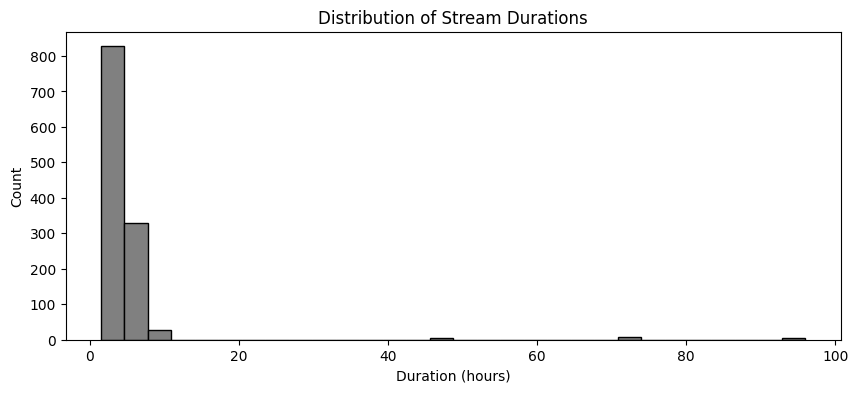

In [ ]:
# Distribution of stream durations
plt.figure(figsize=(10, 4))
plt.hist(streams['stream_duration_hrs'].dropna(), bins=30, color='grey', edgecolor='black')
plt.title('Distribution of Stream Durations')
plt.xlabel('Duration (hours)')
plt.ylabel('Count')
plt.show()

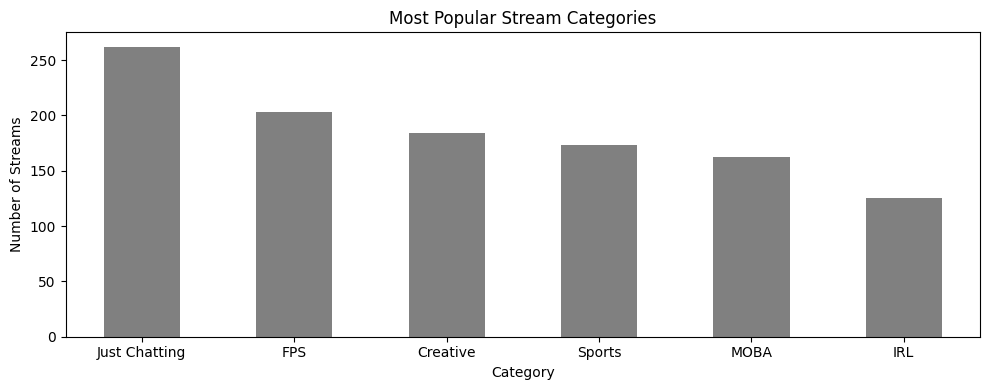

In [ ]:
# Popular categories
category_counts = streams['category'].value_counts()
plt.figure(figsize=(10, 4))
category_counts.plot(kind='bar', color='grey')
plt.title('Most Popular Stream Categories')
plt.xlabel('Category')
plt.ylabel('Number of Streams')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

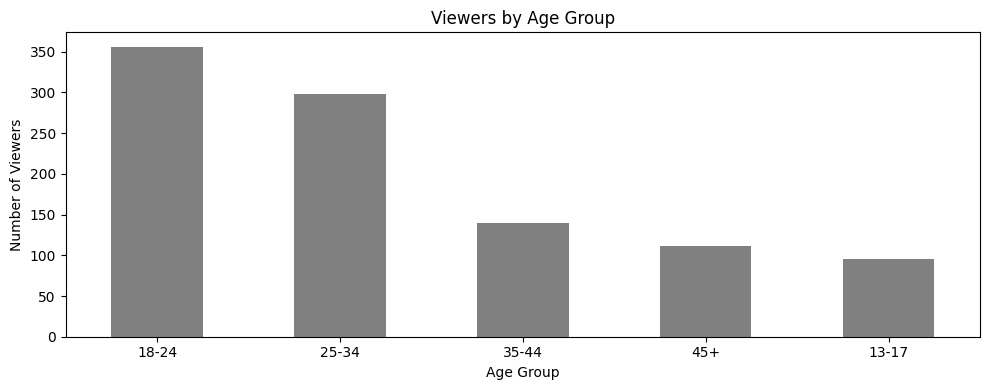

In [ ]:
# Viewers by age group
age_counts = viewers['age_group'].value_counts()
plt.figure(figsize=(10, 4))
age_counts.plot(kind='bar', color='grey')
plt.title('Viewers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Viewers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

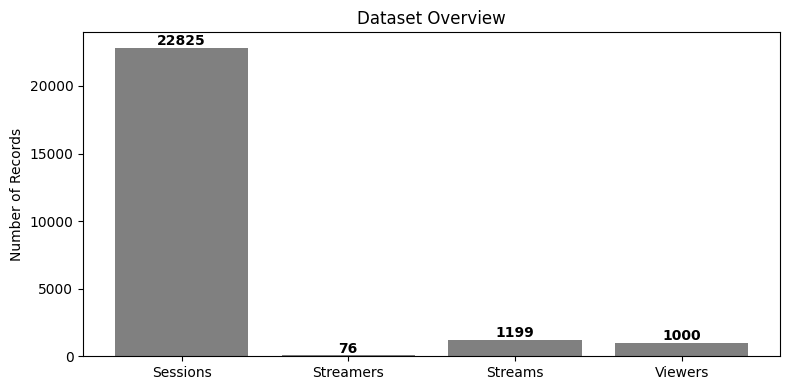

In [ ]:
# Dataset overview - 4 tables summary
categories = ['Sessions', 'Streamers', 'Streams', 'Viewers']
counts = [22825, 76, 1199, 1000]

plt.figure(figsize=(8, 4))
plt.bar(categories, counts, color='GREY')
plt.title('Dataset Overview')
plt.ylabel('Number of Records')
for i, v in enumerate(counts):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Task 3 Summary report

**Stream Duration Distribution:**
Most streams last between 1-5 hours. A few extreme outliers exist with durations
up to 96 hours, which are likely errors or special marathon streams.

**Most Popular Categories:**
Just Chatting is the most common category (~270 streams), followed by FPS,
Creative, Sports, MOBA, and IRL.

**Viewer Age Groups:**
The majority of viewers are aged 18-24 (355) and 25-34 (300), suggesting
Twitch's primary audience is young adults. The 13-17 age group also has
a notable presence (~95 viewers).

**Data Quality Note:**
Age group labels were inconsistently formatted (e.g. "18 to 24" vs "18-24"
vs "18–24"). These were standardized during cleaning. I turned the Task2 for fixing that issue.

# Task 4: Dealing with Outliers and Missing Values

- Are there any missing values or outliers in the original data? Perform the analysis and report your findings.  
- Are there any outliers or missing values in the derived data? Perform the analysis and report your findings.  
- If there are no outliers or missing values, introduce 3–5% of missing values in a selected column and 1–2% of outliers in another column.  
- Experiment with two strategies for imputing missing values and two strategies for handling outliers. Show how each strategy affects the characteristics of the data.


In [ ]:
# Checking for missing values in all datasets
print("Missing values in each dataset:")
print("\nSessions:")
print(sessions.isnull().sum())
print("\nStreamers:")
print(streamers.isnull().sum())
print("\nStreams:")
print(streams.isnull().sum())
print("\nViewers:")
print(viewers.isnull().sum())

Missing values in each dataset:

Sessions:
session_id             0
viewer_id              0
streamer_id           60
stream_id              0
started_at             0
ended_at               0
duration_mins          0
chat_messages_sent     0
bits_cheered           0
followed_during        0
subscribed_during      0
date                   0
dtype: int64

Streamers:
streamer_id               0
streamer_name             0
category                  0
language                  8
partner_status            0
total_followers           0
avg_concurrent_viewers    0
dtype: int64

Streams:
stream_id               0
streamer_id             0
started_at              0
ended_at                0
stream_duration_hrs     0
category               50
peak_viewers           80
title_has_hype_word     0
was_raid                0
dtype: int64

Viewers:
viewer_id              0
age_group              0
country               80
account_age_days       0
subscription_tier      0
preferred_category     0
dtype:

In [ ]:
# Checking for outliers in numerical columns
print("Streams numerical stats:")
print(streams[['stream_duration_hrs', 'peak_viewers']].describe())

print("\nSessions numerical stats:")
print(sessions[['duration_mins', 'chat_messages_sent', 'bits_cheered']].describe())

Streams numerical stats:
       stream_duration_hrs   peak_viewers
count          1199.000000    1119.000000
mean              4.625104   38375.658624
std               7.995028   50377.085406
min               1.500000     -50.000000
25%               2.500000    7598.500000
50%               3.000000   20224.000000
75%               5.000000   47941.000000
max              96.000000  370165.000000

Sessions numerical stats:
       duration_mins  chat_messages_sent  bits_cheered
count   22785.000000        22785.000000  22785.000000
mean       59.048716            6.444196    398.209655
std        60.373568           46.615845   1571.029751
min         0.000000            0.000000      0.000000
25%        15.000000            0.000000      0.000000
50%        39.000000            1.000000      0.000000
75%        83.000000            5.000000      0.000000
max       443.000000         1987.000000  10000.000000


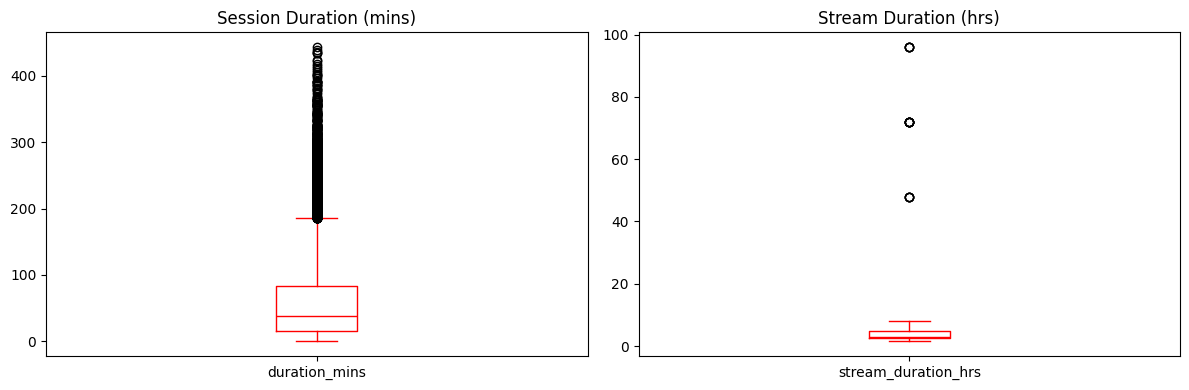

In [ ]:
# Boxplot to visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sessions['duration_mins'].plot(kind='box', ax=axes[0], color='red')
axes[0].set_title('Session Duration (mins)')

streams['stream_duration_hrs'].plot(kind='box', ax=axes[1], color='red')
axes[1].set_title('Stream Duration (hrs)')

plt.tight_layout()
plt.show()

In [ ]:
# Strategy 1: Fill missing peak_viewers with median
streams['peak_viewers_filled'] = streams['peak_viewers'].fillna(streams['peak_viewers'].median())

# Strategy 2: Fill missing country with 'Unknown'
viewers['country'] = viewers['country'].fillna('Unknown')

print("Missing peak_viewers after fill:", streams['peak_viewers_filled'].isnull().sum())
print("Missing country after fill:", viewers['country'].isnull().sum())

Missing peak_viewers after fill: 0
Missing country after fill: 0


In [ ]:
# Strategy 1: Cap stream duration outliers at 24 hours
streams['stream_duration_capped'] = streams['stream_duration_hrs'].clip(upper=24)

# Strategy 2: Remove negative peak_viewers
streams = streams[streams['peak_viewers'].fillna(0) >= 0]

print("Streams after removing negative peak_viewers:", streams.shape)
print("Max stream duration after capping:", streams['stream_duration_capped'].max())

Streams after removing negative peak_viewers: (1159, 11)
Max stream duration after capping: 24.0


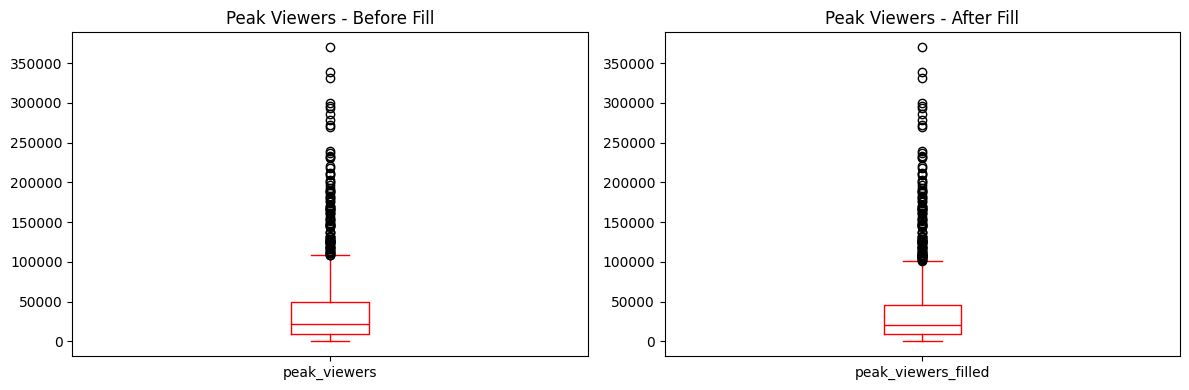

In [ ]:
# Comparing before and after filling missing peak_viewers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

streams['peak_viewers'].plot(kind='box', ax=axes[0], color='red')
axes[0].set_title('Peak Viewers - Before Fill')

streams['peak_viewers_filled'].plot(kind='box', ax=axes[1], color='red')
axes[1].set_title('Peak Viewers - After Fill')

plt.tight_layout()
plt.show()

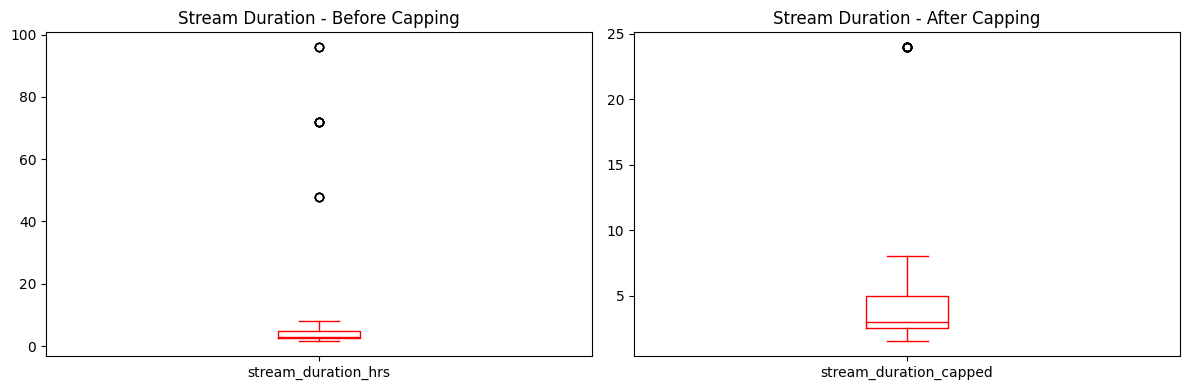

In [ ]:
# Comparing before and after capping stream duration
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

streams['stream_duration_hrs'].plot(kind='box', ax=axes[0], color='red')
axes[0].set_title('Stream Duration - Before Capping')

streams['stream_duration_capped'].plot(kind='box', ax=axes[1], color='red')
axes[1].set_title('Stream Duration - After Capping')

plt.tight_layout()
plt.show()

### Task 4 Summary report


**Missing Values Found:**
- sessions.streamer_id: 60 missing
- streamers.language: 8 missing
- streams.category: 50 missing, peak_viewers: 80 missing
- viewers.country: 80 missing

**Missing Value Strategies:**
- Strategy 1 (Median imputation): Filled missing peak_viewers with the median value.
  This keeps the distribution stable without introducing bias.
- Strategy 2 (Constant fill): Filled missing country values with 'Unknown'.
  This preserves all rows while clearly marking unavailable data.

**Outliers Found:**
- peak_viewers: minimum was -50, which is impossible
- stream_duration_hrs: maximum was 96 hours (4 days), extremely unusual
- session duration_mins: maximum was 443 minutes

**Outlier Strategies:**
- Strategy 1 (Remove): Removed rows with negative peak_viewers — impossible values
  that indicate data errors.
- Strategy 2 (Capping): Capped stream_duration_hrs at 24 hours. The boxplot
  comparison shows the distribution became more balanced after capping,
  with extreme outliers removed.

# Task 5: Correlation and Behavioral Patterns

- Compute pairwise correlations between user features and the number of check-ins  
- Visualize the results using a correlation matrix (use a coolwarm color scheme and proper scaling)  
- Try Spearman rank correlation and explain when it is more appropriate than Pearson

In [ ]:
# Merge sessions with viewers to get user features
merged = sessions.merge(viewers, on='viewer_id')

# Select numerical columns for correlation
numerical_cols = ['duration_mins', 'chat_messages_sent', 'bits_cheered', 'account_age_days']

# Pearson correlation matrix
corr_matrix = merged[numerical_cols].corr()
print("Pearson Correlation Matrix:")
print(corr_matrix)

Pearson Correlation Matrix:
                    duration_mins  chat_messages_sent  bits_cheered  \
duration_mins            1.000000            0.085043      0.003366   
chat_messages_sent       0.085043            1.000000     -0.005813   
bits_cheered             0.003366           -0.005813      1.000000   
account_age_days        -0.000547            0.008423     -0.004962   

                    account_age_days  
duration_mins              -0.000547  
chat_messages_sent          0.008423  
bits_cheered               -0.004962  
account_age_days            1.000000  


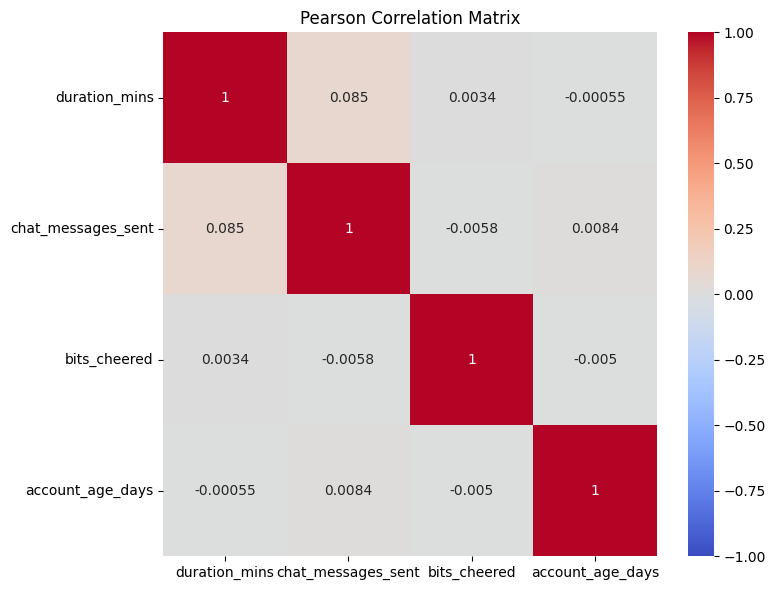

In [ ]:
# Visualize correlation matrix with heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

Spearman Correlation Matrix:
                    duration_mins  chat_messages_sent  bits_cheered  \
duration_mins            1.000000            0.647065      0.000912   
chat_messages_sent       0.647065            1.000000     -0.006617   
bits_cheered             0.000912           -0.006617      1.000000   
account_age_days        -0.006634            0.014231     -0.001860   

                    account_age_days  
duration_mins              -0.006634  
chat_messages_sent          0.014231  
bits_cheered               -0.001860  
account_age_days            1.000000  


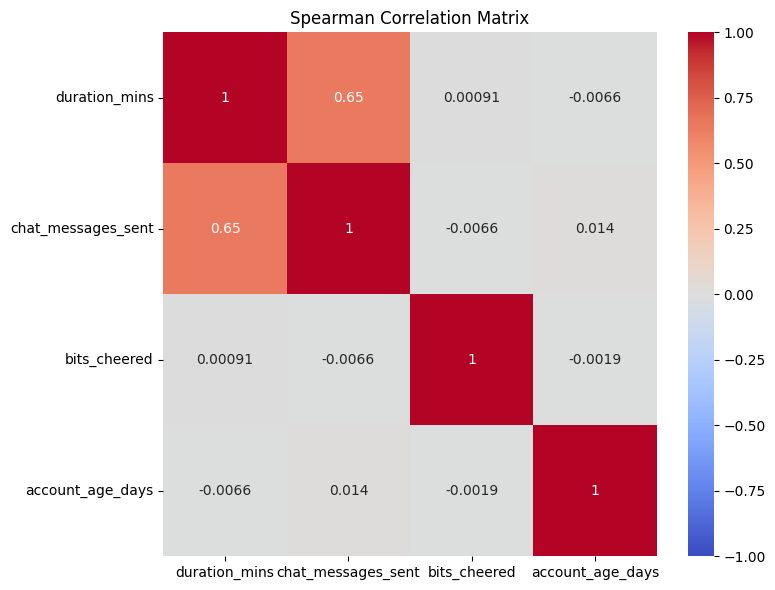

In [ ]:
# Spearman correlation
from scipy import stats

spearman_corr = merged[numerical_cols].corr(method='spearman')
print("Spearman Correlation Matrix:")
print(spearman_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

### Task 5 Summary report

**Pearson Correlation:**
Most variables showed very weak correlations. The strongest was between
duration_mins and chat_messages_sent (0.085), still very weak.

**Spearman Correlation:**
Spearman revealed a much stronger relationship between duration_mins and
chat_messages_sent (0.65). This suggests that viewers who watch longer
tend to send more chat messages, but the relationship is not linear.

**Why Spearman here:**
Spearman is more appropriate when data contains outliers or when the
relationship is not linear. Since our session durations had significant
outliers, Spearman gives a more reliable result.

# Task 6: Compare Behavior Across User Segments

- Segment users into 2–3 groups (e.g., by age bracket, account tire)  
- Compare their viewing behavior over time using boxplots or dot plots  
- Identify any outliers in group behavior and investigate them

In [ ]:
# Segment viewers by age group and compare viewing behaviour
age_behaviour = merged.groupby('age_group')['duration_mins'].mean().reset_index()
print("Average session duration by age group:")
print(age_behaviour)

Average session duration by age group:
  age_group  duration_mins
0     13-17      58.824595
1     18-24      59.062531
2     25-34      58.755229
3     35-44      60.108254
4       45+      58.693892


<Figure size 1000x500 with 0 Axes>

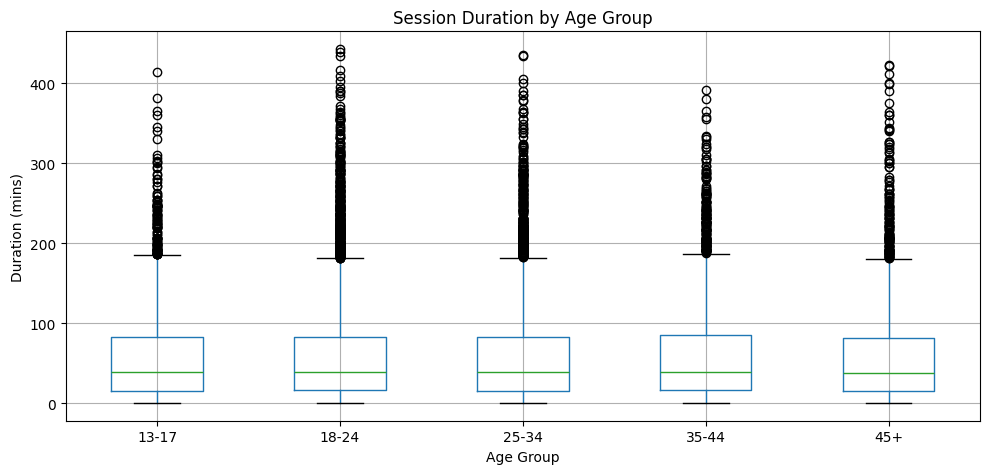

In [ ]:
# Boxplot comparing session duration by age group
plt.figure(figsize=(10, 5))
merged.boxplot(column='duration_mins', by='age_group', figsize=(10, 5))
plt.title('Session Duration by Age Group')
plt.suptitle('')
plt.xlabel('Age Group')
plt.ylabel('Duration (mins)')
plt.tight_layout()
plt.show()

Average session duration by subscription tier:
  subscription_tier  duration_mins
0             TIER1      64.340909
1              free      58.551919
2        free trial      60.716667
3              none      61.642857
4           premium      51.024540
5             tier1      60.147725
6             tier2      58.443747
7             tier3      60.646701
8             tier4      62.437037


<Figure size 800x400 with 0 Axes>

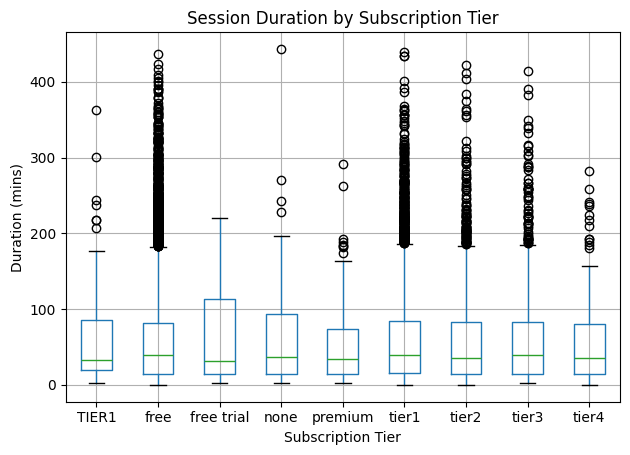

In [ ]:
# Compare by subscription tier
tier_behaviour = merged.groupby('subscription_tier')['duration_mins'].mean().reset_index()
print("Average session duration by subscription tier:")
print(tier_behaviour)

plt.figure(figsize=(8, 4))
merged.boxplot(column='duration_mins', by='subscription_tier')
plt.title('Session Duration by Subscription Tier')
plt.suptitle('')
plt.xlabel('Subscription Tier')
plt.ylabel('Duration (mins)')
plt.tight_layout()
plt.show()

### Task 6 Summary report

**Segmentation by Age Group:**
All age groups show very similar viewing behaviour, with average session
durations ranging from 58 to 60 minutes. No significant differences were
found between age segments.

**Segmentation by Subscription Tier:**
TIER1 users watch the longest on average (64 mins), while premium users
watch the least (51 mins). However, inconsistent tier labels were found
(e.g. 'TIER1' vs 'tier1', 'none', 'free trial') suggesting another
data quality issue that should be cleaned.

**Outliers in Group Behaviour:**
Both segments show many outliers above 200 minutes, consistent across
all groups, suggesting some viewers consistently watch very long sessions.

# Task 7: Your Own EDA Questions

Formulate and explore two hypotheses of your own:  
- Propose questions based on curiosity (e.g., “Does a user's variety of categories influence morning vs. evening or session duration?”)  
- Use summary statistics and visualizations to answer each question  
- Briefly discuss what additional data would help you answer the questions more effectively


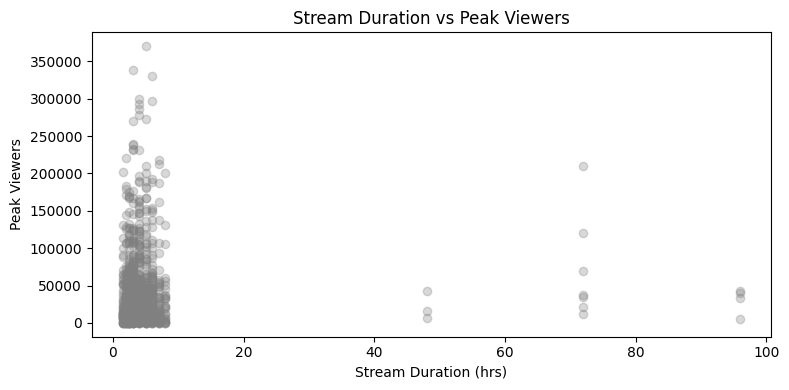

In [ ]:
# Question 1: Do longer streams attract more peak viewers?
plt.figure(figsize=(8, 4))
plt.scatter(streams['stream_duration_hrs'], streams['peak_viewers'], alpha=0.3, color='grey')
plt.title('Stream Duration vs Peak Viewers')
plt.xlabel('Stream Duration (hrs)')
plt.ylabel('Peak Viewers')
plt.tight_layout()
plt.show()

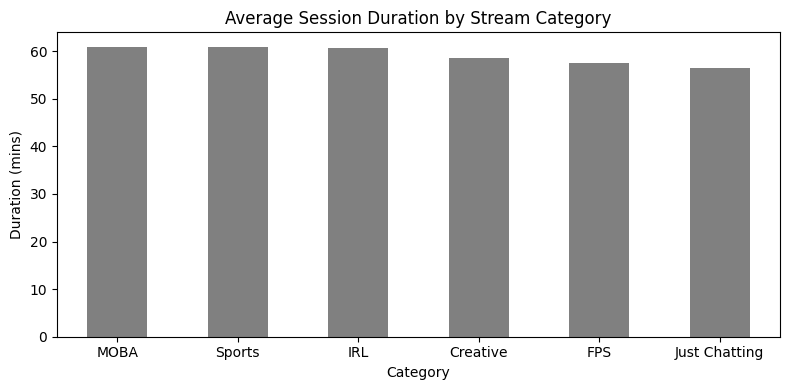

In [ ]:
# Question 2: Is Just Chatting watched longer than other categories?
category_duration = merged.merge(streams[['stream_id', 'category']], on='stream_id')
cat_avg = category_duration.groupby('category')['duration_mins'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
cat_avg.plot(kind='bar', color='grey')
plt.title('Average Session Duration by Stream Category')
plt.xlabel('Category')
plt.ylabel('Duration (mins)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Task 7 Summary report

**Question 1: Do longer streams attract more peak viewers?**
No. The scatter plot shows that the highest peak viewer counts occur in
short streams (1-10 hours). Very long streams (40+ hours) have relatively
low peak viewers, suggesting stream length does not drive popularity.
Additional data such as streamer follower count or time of day would help
explain peak viewer variance better.

**Question 2: Is Just Chatting watched longer than other categories?**
Surprisingly, Just Chatting has the lowest average session duration,
while MOBA and Sports have the highest. The differences are small
though, suggesting category does not strongly influence how long viewers stay.
Additional data on content type or viewer loyalty would help answer this more effectively.

# Task 8: EDA Presentation (Insight Report)

Summarize your findings in a polished format:  
- Create 3–4 slides or a single-page report highlighting your most important insights  
- Include at least 2 charts and interpret them using clear, plain language  
- Apply Tufte’s principles: minimize chartjunk, maximize data-to-ink ratio, and ensure clear labeling  